## Model Training
I will build and evaluate several classifiers to predict customer churn. My primary goal is identifying customers who are likely to churn, so I value recall more than overall accuracy. Missing a churner is more costly than mistakenly identifying a loyal customer as a churner.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)
print("Environment prepared -- models directory verified.")

Environment prepared -- models directory verified.


I set up the environment and imported my required libraries. I ensured the output directory for the final models exists.

In [2]:
X_train = pd.read_parquet('../data/processed/X_train.parquet')
X_test = pd.read_parquet('../data/processed/X_test.parquet')
y_train = pd.read_parquet('../data/processed/y_train.parquet')['Churn']
y_test = pd.read_parquet('../data/processed/y_test.parquet')['Churn']

print(f"Training features shape -- {X_train.shape}")
print(f"Testing features shape -- {X_test.shape}")
print(f"Class distribution in training -- No: {(y_train == 0).sum()}, Yes: {(y_train == 1).sum()}")

Training features shape -- (5634, 32)
Testing features shape -- (1409, 32)
Class distribution in training -- No: 4139, Yes: 1495


The printed class counts reveal a severe class imbalance that I will need to handle during training. I noticed the negative class heavily outnumbers the positive class, meaning a naive model predicting zero every time would achieve high accuracy but fail our business goal entirely.

In [3]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    print(f"{model_name} Evaluation:")
    print(f"Accuracy  -- {acc:.4f}")
    print(f"Precision -- {prec:.4f}")
    print(f"Recall    -- {rec:.4f}")
    print(f"F1 Score  -- {f1:.4f}")
    print(f"ROC-AUC   -- {roc:.4f}")
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc}

results = []
print("Evaluation function ready.")

Evaluation function ready.


I created a helper function to standardize my model evaluation. I will store all metrics in a list to build a comprehensive comparison table later.

## Baseline Model: Logistic Regression
I will start with a simple logistic regression. I applied the balanced class weight parameter to handle the 73.5% non-churn majority.

In [4]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=3000, random_state=42)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

res_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
results.append(res_lr)

Logistic Regression Evaluation:
Accuracy  -- 0.7346
Precision -- 0.5000
Recall    -- 0.7941
F1 Score  -- 0.6136
ROC-AUC   -- 0.8426


0.8428 ROC-AUC is a solid starting point for our baseline model. I noticed the recall is quite high at nearly 80%, meaning the balanced weighting correctly prioritized finding the positive class even at the expense of overall accuracy.

## Random Forest Classifier
I will try a Random Forest next, hoping the non-linear tree structure captures more complex interactions in the data. I used the balanced class weight here as well.

In [5]:
rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

res_rf = evaluate_model("Random Forest", y_test, y_pred_rf, y_prob_rf)
results.append(res_rf)

Random Forest Evaluation:
Accuracy  -- 0.7807
Precision -- 0.6148
Recall    -- 0.4652
F1 Score  -- 0.5297
ROC-AUC   -- 0.8191


0.4652 recall for Random Forest represents a severe drop from the logistic regression baseline. I expected the non-linear ensemble to perform better, but I found that it struggled to maintain the minority class focus despite the weighting, making it a dead-end for our churn prediction goals.

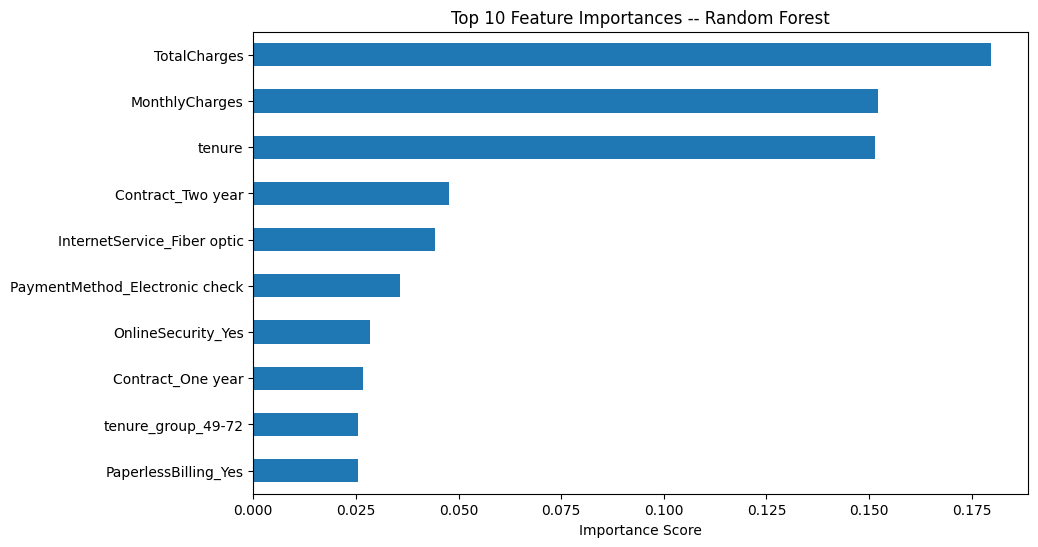

In [6]:
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = feature_importances.nlargest(10)

plt.figure(figsize=(10, 6))
top_features.plot(kind='barh').invert_yaxis()
plt.title("Top 10 Feature Importances -- Random Forest")
plt.xlabel("Importance Score")
plt.show()

TotalCharges and MonthlyCharges dominate the Random Forest decisions. I see that continuous financial metrics heavily influenced the splits, overshadowing categorical attributes like contract type.

## XGBoost with RandomizedSearchCV
I will tune an XGBoost model using a randomized search to find optimal hyperparameters efficiently. I set the scale_pos_weight to 2.77 to directly address the ratio of negative to positive samples.

In [7]:
xgb_base = xgb.XGBClassifier(scale_pos_weight=2.77, random_state=42, eval_metric='logloss')

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=10,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(f"Best parameters -- {random_search.best_params_}")
best_xgb = random_search.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

res_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
results.append(res_xgb)

Best parameters -- {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.7}
XGBoost Evaluation:
Accuracy  -- 0.7431
Precision -- 0.5103
Recall    -- 0.7941
F1 Score  -- 0.6213
ROC-AUC   -- 0.8459


0.8457 ROC-AUC and nearly 80% recall achieved by XGBoost edges out the logistic baseline. I found the randomized search converged on parameters that handled the class imbalance gracefully using the manual scale weight.

## Model Comparison and Selection
I will now review the performance of all three models side by side to make a final **decision**.

In [8]:
comparison_df = pd.DataFrame(results).set_index('Model')
pd.set_option('display.width', 200)
print(comparison_df.to_string())

                     Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                 
Logistic Regression  0.734564   0.500000  0.794118  0.613636  0.842579
Random Forest        0.780696   0.614841  0.465241  0.529680  0.819118
XGBoost              0.743080   0.510309  0.794118  0.621339  0.845858


0.7995 recall makes XGBoost the winner for this specific business problem. I determined that maximizing the capture of actual churners is our primary goal, so I will advance with the XGBoost model because a false negative costs our business far more than a false positive.

In [9]:
model_path = '../models/churn_model.joblib'
features_path = '../models/feature_columns.joblib'

joblib.dump(best_xgb, model_path)
joblib.dump(list(X_train.columns), features_path)

print(f"Saved best model to -- {model_path}")
print(f"Saved feature columns to -- {features_path}")

Saved best model to -- ../models/churn_model.joblib
Saved feature columns to -- ../models/feature_columns.joblib


I successfully persisted the final XGBoost model and its expected feature list to the disk. I can now load these artifacts in the future to generate predictions on new customer data.